# Hotel Recommendation & Customer Insights
## Modeling, Evaluation & Deployment Artifacts

This notebook contains the end-to-end machine learning workflow
behind the deployed Streamlit application.

It covers:
- data preparation and exploratory analysis;
- TF-IDF + Cosine content-based recommendation;
- Gensim comparison;
- customer-group recommendation with PySpark ALS and Ridge;
- model evaluation;
- hotel review insights;
- export and validation of deployment artifacts.

Live application: https://hotel-recommendation-insights.streamlit.app/

# 1. Business Understanding

The project addresses two recommendation tasks:

- **Content-Based Filtering:** the user selects a hotel, and the system returns hotels with similar content and characteristics.
- **Collaborative Filtering:** the system predicts ratings and recommends hotels that the user has not yet rated.

# 2. Environment Setup

In [123]:
# Chỉ cài thư viện khi môi trường chưa có.

import importlib.util
import subprocess
import sys

packages = {
    "gensim": "gensim>=4.3.3",
    "pyspark": "pyspark==3.5.1",
}

missing_packages = [
    package
    for module, package in packages.items()
    if importlib.util.find_spec(module) is None
]

if missing_packages:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *missing_packages]
    )

print("Setup completed.")

Setup completed.


In [124]:
# Import thư viện.

import html
import os
import re
import sys
import unicodedata
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

SEED = 42
np.random.seed(SEED)
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

IN_COLAB = (
    "COLAB_RELEASE_TAG" in os.environ
    or "google.colab" in sys.modules
)

print("Running in Google Colab:", IN_COLAB)

Running in Google Colab: True


# 3. Load Data

In [125]:
# Colab sử dụng /content. Môi trường kiểm tra local sử dụng /mnt/data.

DATA_DIR = Path("/content") if IN_COLAB else Path("/mnt/data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

hotel_info_path = DATA_DIR / "hotel_info.csv"
hotel_comments_path = DATA_DIR / "hotel_comments.csv"

if IN_COLAB and (
    not hotel_info_path.exists()
    or not hotel_comments_path.exists()
):
    from google.colab import files
    print("Upload hotel_info.csv và hotel_comments.csv")
    files.upload()

if not hotel_info_path.exists() or not hotel_comments_path.exists():
    raise FileNotFoundError("Không tìm thấy hai file CSV.")

print("Data folder:", DATA_DIR)

Data folder: /content


In [126]:
# Đọc dữ liệu gốc.

hotel_info_raw = pd.read_csv(hotel_info_path)
hotel_comments_raw = pd.read_csv(
    hotel_comments_path,
    encoding="utf-8-sig",
)

print("hotel_info_raw:", hotel_info_raw.shape)
print("hotel_comments_raw:", hotel_comments_raw.shape)

display(hotel_info_raw.head(3))
display(hotel_comments_raw.head(3))

hotel_info_raw: (740, 14)
hotel_comments_raw: (80314, 13)


,num,Hotel_ID,Hotel_Name,Hotel_Rank,Hotel_Address,Total_Score,Location,Cleanliness,Service,Facilities,Value_for_money,Comfort_and_room_quality,comments_count,Hotel_Description
0,1,1_1,Khách sạn Mường Thanh Luxury Nha Trang (Muong Thanh Luxury Nha Trang Hotel),5 sao trên 5,"60 Trần Phú, Lộc Thọ, Nha Trang, Việt Nam","8,8","9,4","8,9","8,9","8,7","8,7","8,3",1269,Khách sạn Mường Thanh Luxury Nha Trang - Nơi lưu trú tuyệt vời tại Nha Trang\n\nKhách sạn Mường Thanh Luxury Nha Tra...
1,2,1_2,ALPHA BIRD NHA TRANG,4 sao trên 5,"51/19/37 Tue Tinh St, Loc Tho Ward, Nha Trang, Lộc Thọ, Nha Trang, Việt Nam, 650000","7,7","7,8","7,6","8,1","7,5","8,1",NaN,337,"ALPHA BIRD NHA TRANG - Khách sạn 4.0 sao tại Nha Trang, Việt Nam\n\nALPHA BIRD NHA TRANG là một khách sạn 4.0 sao tọ..."
2,3,1_3,Khách sạn Aaron (Aaron Hotel),3.5 sao trên 5,"6Trần Quang Khải, Lộc Thọ, Nha Trang, Việt Nam, 65000","8,5","8,9","8,7","8,8","8,1","8,5",NaN,300,"Khách sạn Aaron - Nơi nghỉ dưỡng tuyệt vời tại Nha Trang\n\nKhách sạn Aaron, một khách sạn 3.5 sao tọa lạc tại thành..."


,num,Hotel ID,Reviewer ID,Reviewer Name,Nationality,Group Name,Room Type,Stay Details,Score,Score Level,Title,Body,Review Date
0,1,1_1,1_1_1,MARIKO,Nhật Bản,Cặp đôi,Phòng Deluxe 2 Giường đơn Nhìn ra Biển,Đã ở 3 đêm vào Tháng 7 năm 2023,"10,0",Trên cả tuyệt vời,Cao nhất‼︎”,Tôi đã ở cùng chủ nhân trong 4 đêm. Nhân viên rất thân thiện. Tầm nhìn từ phòng nhìn ra biển rộng lớn và tôi đã cảm ...,Đã nhận xét vào 30 tháng 7 2023
1,2,1_1,1_1_2,Hong,Việt Nam,Đi công tác,Phòng Deluxe 2 Giường đơn Nhìn ra Biển,Đã ở 1 đêm vào Tháng 9 năm 2022,"10,0",Trên cả tuyệt vời,Tháng 8”,Lựa chọn Mường Thanh vì giá cả phù hợp. Đặt Online được nhiều ưu đãi. Bữa sáng khá phong phú và đầy đủ dưỡng chất. M...,Đã nhận xét vào 05 tháng 9 2022
2,3,1_1,1_1_3,Guai,Việt Nam,Cặp đôi,Deluxe Hướng biển giường đôi,Đã ở 1 đêm vào Tháng 6 năm 2024,"9,2",Trên cả tuyệt vời,Du lịch tại Nha Trang”,"Lần này đến với Nha Trang, tôi book phòng tại khách sạn Mường Thanh Luxury. Khách sạn trên đường Trần Phú, có view r...",Đã nhận xét vào 25 tháng 6 2024


`shape` có dạng `(số dòng, số cột)`. Mỗi dòng của `hotel_info` là một khách sạn; mỗi dòng của `hotel_comments` là một review.

# 4. Data Understanding

In [127]:
# Tóm tắt kiểu dữ liệu, missing values và số giá trị khác nhau.

def summarize_dataframe(df):
    return pd.DataFrame({
        "data_type": df.dtypes.astype(str),
        "missing_values": df.isna().sum(),
        "missing_percent": (df.isna().mean() * 100).round(2),
        "unique_values": df.nunique(dropna=True),
    })

print("HOTEL INFO")
display(summarize_dataframe(hotel_info_raw))

print("HOTEL COMMENTS")
display(summarize_dataframe(hotel_comments_raw))

#print(hotel_info_raw["Hotel_Rank"].value_counts(dropna=False))

HOTEL INFO


,data_type,missing_values,missing_percent,unique_values
num,int64,0,0.00,740
Hotel_ID,object,0,0.00,740
Hotel_Name,object,0,0.00,740
Hotel_Rank,object,0,0.00,10
Hotel_Address,object,0,0.00,361
Total_Score,object,0,0.00,54
Location,object,327,44.19,42
Cleanliness,object,328,44.32,47
Service,object,367,49.59,47
Facilities,object,370,50.00,46


HOTEL COMMENTS


,data_type,missing_values,missing_percent,unique_values
num,int64,0,0.00,80314
Hotel ID,object,0,0.00,473
Reviewer ID,object,0,0.00,80314
Reviewer Name,object,86,0.11,8190
Nationality,object,0,0.00,110
Group Name,object,0,0.00,6
Room Type,object,0,0.00,1331
Stay Details,object,0,0.00,899
Score,object,0,0.00,22
Score Level,object,0,0.00,4


`Comfort_and_room_quality`, `Facilities` và `Service` có tỷ lệ thiếu cao.

In [128]:
# Kiểm tra Hotel ID, Reviewer ID và duplicate.

hotel_ids_info = set(hotel_info_raw["Hotel_ID"].astype(str))
hotel_ids_comments = set(hotel_comments_raw["Hotel ID"].astype(str))

reviewer_counts = (
    hotel_comments_raw.groupby("Reviewer ID")["Hotel ID"].nunique()
)

audit_table = pd.DataFrame({
    "metric": [
        "Khách sạn trong hotel_info",
        "Khách sạn trong hotel_comments",
        "Hotel ID xuất hiện ở cả hai bảng",
        "Số review",
        "Số Reviewer ID",
        "Số khách sạn lớn nhất của một Reviewer ID",
        "Dòng trùng trong hotel_info",
        "Dòng trùng trong hotel_comments",
    ],
    "value": [
        hotel_info_raw["Hotel_ID"].nunique(),
        hotel_comments_raw["Hotel ID"].nunique(),
        len(hotel_ids_info & hotel_ids_comments),
        len(hotel_comments_raw),
        hotel_comments_raw["Reviewer ID"].nunique(),
        reviewer_counts.max(),
        hotel_info_raw.duplicated().sum(),
        hotel_comments_raw.duplicated().sum(),
    ],
})

display(audit_table)

,metric,value
0,Khách sạn trong hotel_info,740
1,Khách sạn trong hotel_comments,473
2,Hotel ID xuất hiện ở cả hai bảng,341
3,Số review,80314
4,Số Reviewer ID,80314
5,Số khách sạn lớn nhất của một Reviewer ID,1
6,Dòng trùng trong hotel_info,0
7,Dòng trùng trong hotel_comments,0


### Nhận xét

- Các cột điểm đang ở dạng chuỗi, ví dụ `"8,8"`.
- Hạng sao đang ở dạng chuỗi, ví dụ `"5 sao trên 5"`.
- Ngày review là câu tiếng Việt.
- Hotel ID không khớp hoàn toàn giữa hai bảng.
- Mỗi `Reviewer ID` chỉ đánh giá một khách sạn, nên không đủ lịch sử để học sở thích cá nhân.

# 5. Data Preparation

In [129]:
# Đổi tên cột

hotel_info = hotel_info_raw.rename(columns={
    "Hotel_ID": "hotel_id",
    "Hotel_Name": "hotel_name",
    "Hotel_Rank": "hotel_rank_raw",
    "Hotel_Address": "hotel_address",
    "Total_Score": "total_score",
    "Location": "location",
    "Cleanliness": "cleanliness",
    "Service": "service",
    "Facilities": "facilities",
    "Value_for_money": "value_for_money",
    "Comfort_and_room_quality": "comfort_and_room_quality",
    "Hotel_Description": "hotel_description",
}).drop(columns=["num"], errors="ignore")

hotel_comments = hotel_comments_raw.rename(columns={
    "Hotel ID": "hotel_id",
    "Reviewer ID": "reviewer_id",
    "Reviewer Name": "reviewer_name",
    "Nationality": "nationality",
    "Group Name": "group_name",
    "Room Type": "room_type",
    "Stay Details": "stay_details",
    "Score": "score",
    "Score Level": "score_level",
    "Title": "title",
    "Body": "body",
    "Review Date": "review_date_raw",
}).drop(columns=["num"], errors="ignore")

print("Columns renamed.")

Columns renamed.


In [130]:
# Chuyển "8,8" thành số 8.8.

def convert_decimal_comma(series):
    cleaned = (
        series.astype("string")
        .str.strip()
        .replace({"No information": pd.NA, "": pd.NA})
        .str.replace(",", ".", regex=False)
    )
    return pd.to_numeric(cleaned, errors="coerce")

hotel_score_columns = [
    "total_score",
    "location",
    "cleanliness",
    "service",
    "facilities",
    "value_for_money",
    "comfort_and_room_quality",
]

for column in hotel_score_columns:
    hotel_info[column] = convert_decimal_comma(hotel_info[column])

hotel_comments["score"] = convert_decimal_comma(hotel_comments["score"])

print("Score columns converted to numeric.")

Score columns converted to numeric.


In [131]:
# Tách hạng sao: "5 sao trên 5" -> 5.

hotel_info["hotel_rank"] = pd.to_numeric(
    hotel_info["hotel_rank_raw"]
    .astype("string")
    .str.extract(r"(\d+(?:\.\d+)?)", expand=False),
    errors="coerce",
)

# Tách ngày review tiếng Việt thành datetime.

date_parts = hotel_comments["review_date_raw"].str.extract(
    r"(?P<day>\d{1,2})\s+tháng\s+"
    r"(?P<month>\d{1,2})\s+"
    r"(?P<year>\d{4})"
)

hotel_comments["review_date"] = pd.to_datetime({
    "year": pd.to_numeric(date_parts["year"], errors="coerce"),
    "month": pd.to_numeric(date_parts["month"], errors="coerce"),
    "day": pd.to_numeric(date_parts["day"], errors="coerce"),
}, errors="coerce")

print("Hotel rank and review date prepared.")

Hotel rank and review date prepared.


In [132]:
# Xóa khoảng trắng thừa và duplicate.

for column in hotel_info.select_dtypes(include=["object", "string"]).columns:
    hotel_info[column] = hotel_info[column].astype("string").str.strip()

for column in hotel_comments.select_dtypes(include=["object", "string"]).columns:
    hotel_comments[column] = hotel_comments[column].astype("string").str.strip()

hotel_info = hotel_info.drop_duplicates().reset_index(drop=True)
hotel_comments = hotel_comments.drop_duplicates().reset_index(drop=True)

# Tạo cột review từ tittle và body.
hotel_comments["review_text"] = (
    hotel_comments["title"].fillna("")
    + " "
    + hotel_comments["body"].fillna("")
).str.strip()

print("Basic cleaning completed.")

Basic cleaning completed.


In [133]:
# Kiểm tra kết quả làm sạch và khả năng join hai bảng.

reviews_with_hotel = hotel_comments.merge(
    hotel_info[["hotel_id", "hotel_name", "hotel_rank", "total_score"]],
    on="hotel_id",
    how="left",
)

validation_table = pd.DataFrame({
    "check": [
        "hotel_info rows",
        "hotel_comments rows",
        "hotel_info duplicate rows",
        "hotel_comments duplicate rows",
        "Review score nằm trong [0, 10]",
        "Review date parse thành công (%)",
        "Review ghép được tên khách sạn (%)",
    ],
    "value": [
        len(hotel_info),
        len(hotel_comments),
        hotel_info.duplicated().sum(),
        hotel_comments.duplicated().sum(),
        hotel_comments["score"].dropna().between(0, 10).all(),
        round(hotel_comments["review_date"].notna().mean() * 100, 2),
        round(reviews_with_hotel["hotel_name"].notna().mean() * 100, 2),
    ],
})
#print(reviews_with_hotel["hotel_name"].isna().sum)
display(validation_table)

,check,value
0,hotel_info rows,740
1,hotel_comments rows,80314
2,hotel_info duplicate rows,0
3,hotel_comments duplicate rows,0
4,"Review score nằm trong [0, 10]",True
5,Review date parse thành công (%),100.0
6,Review ghép được tên khách sạn (%),86.98


### Missing values

Notebook không điền trung bình cho mọi giá trị thiếu:

- văn bản thiếu được thay bằng chuỗi rỗng khi tạo Content-Based features
- rating thiếu không được dùng cho Collaborative Filtering

In [134]:
# Lưu dữ liệu sạch để tái sử dụng.

processed_dir = DATA_DIR / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

hotel_info.to_csv(processed_dir / "hotel_info_clean.csv", index=False)
hotel_comments.to_csv(processed_dir / "hotel_comments_clean.csv", index=False)

print("Saved to:", processed_dir)

Saved to: /content/processed


# 6. EDA

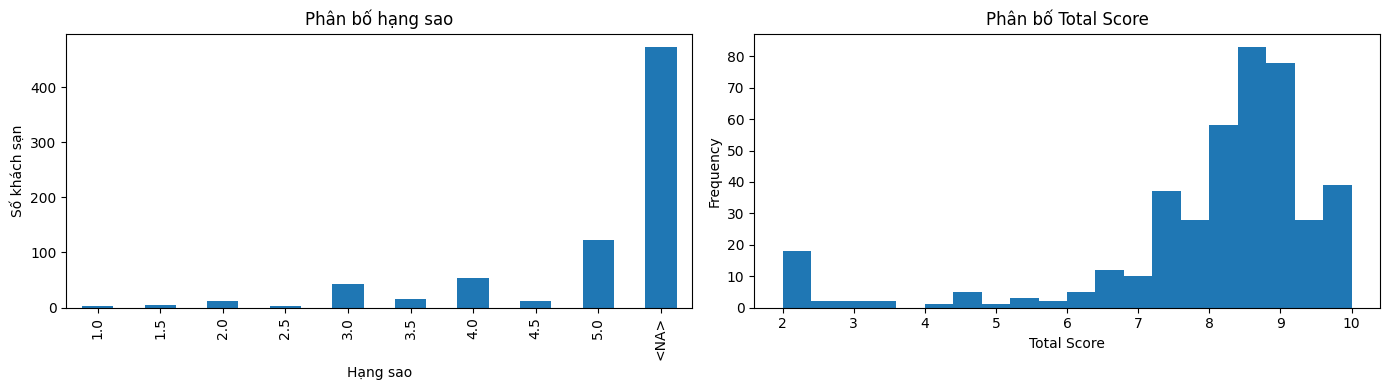

In [135]:
# Phân bố hạng sao và điểm tổng.

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

hotel_info["hotel_rank"].value_counts(dropna=False).sort_index().plot(
    kind="bar",
    ax=axes[0],
)
axes[0].set_title("Phân bố hạng sao")
axes[0].set_xlabel("Hạng sao")
axes[0].set_ylabel("Số khách sạn")

hotel_info["total_score"].dropna().plot(
    kind="hist",
    bins=20,
    ax=axes[1],
)
axes[1].set_title("Phân bố Total Score")
axes[1].set_xlabel("Total Score")

plt.tight_layout()
plt.show()

#print(hotel_info["hotel_rank"].isna().sum())

In [136]:
# Thống kê mô tả các cột điểm.

display(
    hotel_info[[
        "total_score",
        "location",
        "cleanliness",
        "service",
        "facilities",
        "value_for_money",
        "comfort_and_room_quality",
        "comments_count",
    ]].describe().round(2)
)

,total_score,location,cleanliness,service,facilities,value_for_money,comfort_and_room_quality,comments_count
count,414.0,413.0,412.0,373.0,370.0,410.0,51.0,740.00
mean,8.01,8.27,8.12,8.3,7.9,8.18,8.3,94.40
std,1.76,1.92,1.91,1.74,1.7,1.89,1.21,258.10
min,2.0,2.0,2.0,2.0,2.0,2.0,3.0,0.00
25%,7.7,8.2,7.8,8.0,7.43,8.0,7.7,0.00
50%,8.5,8.7,8.7,8.8,8.25,8.7,8.5,0.00
75%,8.9,9.3,9.2,9.2,8.9,9.2,9.1,28.25
max,10.0,10.0,10.0,10.0,10.0,10.0,10.0,1464.00


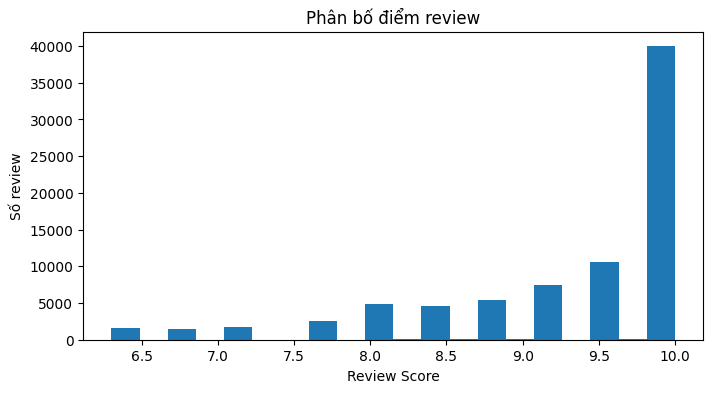

In [137]:
# Biểu đồ phân bố review score

hotel_comments["score"].plot(
    kind="hist",
    bins=20,
    figsize=(8, 4),
)

plt.title("Phân bố điểm review")
plt.xlabel("Review Score")
plt.ylabel("Số review")
plt.show()

Điểm review lệch mạnh về phía các giá trị cao. Vì vậy, một model chỉ
dự đoán gần điểm trung bình cũng có thể đạt RMSE tương đối thấp.
Do đó, cần so sánh ALS và Ridge với Global Mean Baseline.

# 7. Content-Based Recommendation

Mỗi khách sạn được biểu diễn bằng:

```text
Hotel Description + Hotel Address + Hotel Rank
```

## 7.1. Preparation

In [138]:
# Stopwords ngắn để notebook không phụ thuộc file ngoài.

vietnamese_stopwords = [
    "và", "là", "của", "có", "cho", "với", "trong", "tại",
    "một", "các", "được", "những", "này", "đến", "từ", "khi",
]


def clean_text(value):
    if pd.isna(value):
        return ""

    text = html.unescape(str(value))
    text = unicodedata.normalize("NFKC", text).lower()
    text = re.sub(r"[^\w\sÀ-ỹ]", " ", text, flags=re.UNICODE)
    return re.sub(r"\s+", " ", text).strip()

def build_rank_token(value):
    if pd.isna(value):
        return ""

    rank_value = (
        f"{float(value):g}"
        .replace(".", "_")
    )

    return f"rank{rank_value}"


hotel_name_text = (
    hotel_info["hotel_name"]
    .fillna("")
    .map(clean_text)
)

description_text = (
    hotel_info["hotel_description"]
    .fillna("")
    .map(clean_text)
)

address_text = (
    hotel_info["hotel_address"]
    .fillna("")
    .map(clean_text)
)

rank_text = (
    hotel_info["hotel_rank"]
    .map(build_rank_token)
)


hotel_info["content_text"] = (
    hotel_name_text
    + " "
    + description_text
    + " "
    + address_text
    + " "
    + rank_text
).str.strip()


display(
    hotel_info[
        [
            "hotel_name",
            "hotel_rank",
            "content_text",
        ]
    ].head(3)
)

,hotel_name,hotel_rank,content_text
0,Khách sạn Mường Thanh Luxury Nha Trang (Muong Thanh Luxury Nha Trang Hotel),5.0,khách sạn mường thanh luxury nha trang muong thanh luxury nha trang hotel khách sạn mường thanh luxury nha trang nơi...
1,ALPHA BIRD NHA TRANG,4.0,alpha bird nha trang alpha bird nha trang khách sạn 4 0 sao tại nha trang việt nam alpha bird nha trang là một khách...
2,Khách sạn Aaron (Aaron Hotel),3.5,khách sạn aaron aaron hotel khách sạn aaron nơi nghỉ dưỡng tuyệt vời tại nha trang khách sạn aaron một khách sạn 3 5...


## 7.2. TF-IDF + Cosine Similarity

In [139]:
# Chuyển nội dung thành TF-IDF vectors và tính cosine similarity.

tfidf_vectorizer = TfidfVectorizer(
    stop_words=vietnamese_stopwords,
    ngram_range=(1, 2),
    max_features=15_000,
)

tfidf_matrix = tfidf_vectorizer.fit_transform(hotel_info["content_text"])
cosine_matrix = cosine_similarity(tfidf_matrix)

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (740, 15000)


In [140]:
# Validation for context search
feature_names = set(
    tfidf_vectorizer
    .get_feature_names_out()
)

print(
    "rank5 in vocabulary:",
    "rank5" in feature_names,
)

print(
    "cam ranh in vocabulary:",
    "cam ranh" in feature_names,
)

assert "rank5" in feature_names

assert (
    tfidf_matrix.shape[0]
    == len(hotel_info)
)

print(
    "Updated content features "
    "validated successfully."
)

rank5 in vocabulary: True
cam ranh in vocabulary: True
Updated content features validated successfully.


In [141]:
def find_hotel_index(hotel_name):
    # Tìm chính xác trước.
    exact = hotel_info.index[
        hotel_info["hotel_name"].astype(str).str.casefold()
        == str(hotel_name).casefold()
    ].tolist()

    if exact:
        return exact[0]

    # Nếu không có, tìm theo một phần tên.
    partial = hotel_info.index[
        hotel_info["hotel_name"].astype(str).str.contains(
            str(hotel_name),
            case=False,
            regex=False,
            na=False,
        )
    ].tolist()

    if len(partial) == 1:
        return partial[0]

    raise ValueError("Không tìm thấy hoặc tên khách sạn chưa đủ cụ thể.")


def recommend_by_cosine(hotel_name, top_n=10):
    hotel_index = find_hotel_index(hotel_name)
    scores = cosine_matrix[hotel_index]

    ranked_indices = np.argsort(scores)[::-1]
    ranked_indices = [
        index for index in ranked_indices
        if index != hotel_index
    ][:top_n]

    result = hotel_info.loc[
        ranked_indices,
        ["hotel_id", "hotel_name", "hotel_rank", "total_score", "hotel_address"],
    ].copy()

    result.insert(2, "similarity_score", scores[ranked_indices])
    result.insert(0, "rank", range(1, len(result) + 1))

    return result.reset_index(drop=True)

In [142]:
sample_hotel = (
    "Khu nghỉ dưỡng Alma Cam Ranh "
    "(Alma Resort Cam Ranh)"
)

cosine_results = recommend_by_cosine(sample_hotel, top_n=10)
display(cosine_results)

,rank,hotel_id,hotel_name,similarity_score,hotel_rank,total_score,hotel_address
0,1,5_24,Khu Nghỉ Dưỡng Swandor Cam Ranh-Trọn Gói (Swandor Cam Ranh Resort-Ultra All Inclusive),0.704909,5.0,8.6,"Lô D13, Km số 11, Đại lộ Nguyễn Tất Thành, Cam Hải Đông, Nha Trang, Việt Nam, 65000"
1,2,7_26,Khu Nghỉ Dưỡng Radisson Blu Vịnh Cam Ranh (Radisson Blu Resort Cam Ranh),0.696875,5.0,8.8,"D12 ABC Đại lộ Nguyễn Tất Thành, Cam Hải Đông, Cam Ranh, Cam Hải Đông, Nha Trang, Việt Nam, 65000"
2,3,13_17,Khu nghỉ dưỡng và Spa Cam Ranh Riviera Beach - Trọn gói (Cam Ranh Riviera Beach Resort and Spa - All Inclusive),0.688823,5.0,8.4,"Cam Ranh, Cam Hải Đông, Nha Trang, Việt Nam, 650000"
3,4,3_3,Khu Nghỉ Dưỡng Movenpick Cam Ranh (Movenpick Resort Cam Ranh),0.686320,5.0,8.7,"Plot D12 ABC, Cam Hải Đông, Nha Trang, Việt Nam, 57000"
4,5,9_24,Khu nghỉ dưỡng Selectum Noa Cam Ranh (Selectum Noa Resort Cam Ranh),0.668040,5.0,8.6,"Lot X5B &amp; TT3A, Zone 2, Northern Peninsula Cam Ranh, Cam Hải Đông, Nha Trang, Việt Nam, 57600"
5,6,2_15,Khu nghỉ dưỡng Duyên Hà - Cam Ranh (Duyen Ha Resort Cam Ranh),0.667252,5.0,8.8,"Lô D9B, Khu 3, Xã Cam Hải Đông, Cam Hải Đông, Nha Trang, Việt Nam, 650000"
6,7,7_7,Khu nghỉ dưỡng Alibu Nha Trang (Alibu Resort Nha Trang),0.659591,5.0,8.9,"Đường Phạm Văn Đồng, Tổ 14 Đường Đệ, Phường Vĩnh Hòa, Thành phố Nha Trang, Vĩnh Hòa, Nha Trang, Việt Nam, 650000"
7,8,5_3,Ana Mandara Cam Ranh,0.627740,5.0,8.8,"Lô D6A – Khu 2 – Khu Du Lịch Bắc Bán Đảo Cam Ranh – Xã Cam Hải Đông, Huyện Cam Lâm, Tỉnh Khánh Hòa , Cam Hải Đông, N..."
8,9,11_21,La Paloma Villa,0.627401,3.0,8.0,"1 Hòn Chồng, Phường Vĩnh Phước số mới 80 Hòn Chồng, Phường Vĩnh Phước, Vĩnh Phước, Nha Trang, Việt Nam, 650000"
9,10,4_1,Khu nghỉ dưỡng Khách sạn & Spa Champa Island Nha Trang (Champa Island Nha Trang - Resort Hotel & Spa),0.626456,5.0,8.9,"304 - Đường 2/4, Phường Vĩnh Phước, Ngọc Hiệp, Nha Trang, Việt Nam, 57000"


`similarity_score` càng gần 1 thì nội dung càng giống. Đây là độ tương đồng về nội dung, không phải xác suất đặt phòng.

## 7.3. Gensim

In [143]:
from gensim import corpora, models, similarities
from gensim.utils import simple_preprocess

stopword_set = set(vietnamese_stopwords)

hotel_tokens = [
    [
        token
        for token in simple_preprocess(text, deacc=False, min_len=2)
        if token not in stopword_set
    ]
    for text in hotel_info["content_text"]
]

dictionary = corpora.Dictionary(hotel_tokens)
corpus = [dictionary.doc2bow(tokens) for tokens in hotel_tokens]
gensim_tfidf = models.TfidfModel(corpus)

gensim_index = similarities.SparseMatrixSimilarity(
    gensim_tfidf[corpus],
    num_features=len(dictionary),
)

print("Gensim vocabulary size:", len(dictionary))

Gensim vocabulary size: 5172


In [144]:
def recommend_by_gensim(hotel_name, top_n=10):
    hotel_index = find_hotel_index(hotel_name)
    query_vector = gensim_tfidf[corpus[hotel_index]]
    scores = gensim_index[query_vector]

    ranked_indices = np.argsort(scores)[::-1]
    ranked_indices = [
        index for index in ranked_indices
        if index != hotel_index
    ][:top_n]

    result = hotel_info.loc[
        ranked_indices,
        ["hotel_id", "hotel_name", "hotel_rank", "total_score", "hotel_address"],
    ].copy()

    result.insert(2, "similarity_score", scores[ranked_indices])
    result.insert(0, "rank", range(1, len(result) + 1))

    return result.reset_index(drop=True)


gensim_results = recommend_by_gensim(sample_hotel, top_n=10)
display(gensim_results)

,rank,hotel_id,hotel_name,similarity_score,hotel_rank,total_score,hotel_address
0,1,13_17,Khu nghỉ dưỡng và Spa Cam Ranh Riviera Beach - Trọn gói (Cam Ranh Riviera Beach Resort and Spa - All Inclusive),0.679046,5.0,8.4,"Cam Ranh, Cam Hải Đông, Nha Trang, Việt Nam, 650000"
1,2,5_24,Khu Nghỉ Dưỡng Swandor Cam Ranh-Trọn Gói (Swandor Cam Ranh Resort-Ultra All Inclusive),0.671992,5.0,8.6,"Lô D13, Km số 11, Đại lộ Nguyễn Tất Thành, Cam Hải Đông, Nha Trang, Việt Nam, 65000"
2,3,7_26,Khu Nghỉ Dưỡng Radisson Blu Vịnh Cam Ranh (Radisson Blu Resort Cam Ranh),0.662522,5.0,8.8,"D12 ABC Đại lộ Nguyễn Tất Thành, Cam Hải Đông, Cam Ranh, Cam Hải Đông, Nha Trang, Việt Nam, 65000"
3,4,2_15,Khu nghỉ dưỡng Duyên Hà - Cam Ranh (Duyen Ha Resort Cam Ranh),0.642921,5.0,8.8,"Lô D9B, Khu 3, Xã Cam Hải Đông, Cam Hải Đông, Nha Trang, Việt Nam, 650000"
4,5,3_3,Khu Nghỉ Dưỡng Movenpick Cam Ranh (Movenpick Resort Cam Ranh),0.641029,5.0,8.7,"Plot D12 ABC, Cam Hải Đông, Nha Trang, Việt Nam, 57000"
5,6,6_5,The Empyrean Cam Ranh Beach Resort,0.619160,5.0,8.0,"Bai Dai, Cam Hải Đông, Nha Trang, Việt Nam, 650000"
6,7,1_4,Panorama Star Beach Nha Trang,0.615000,5.0,8.8,"02 Nguyen Thi Minh Khai, Lộc Thọ, Nha Trang, Việt Nam, 650000"
7,8,2_20,Khách sạn V Nha Trang (V Hotel Nha Trang),0.612761,4.0,8.6,"8 Hung Vuong, Lộc Thọ, Nha Trang, Việt Nam, 57000"
8,9,3_28,The Costa Nha Trang (The Costa Nha Trang Residences),0.612032,5.0,8.6,"32 – 34 Trần Phú, Lộc Thọ, Nha Trang, Việt Nam, 650000"
9,10,32_14,An Vista Hotel,0.609804,<NA>,8.9,"96/12 Trần Phú - Phường Lộc Thọ - TP Nha Trang- Khánh Hòa, Lộc Thọ, Nha Trang, Việt Nam, 650000"


## 7.4. Compare the result

In [145]:
common_count = len(
    set(cosine_results["hotel_id"])
    & set(gensim_results["hotel_id"])
)

print(f"Số khách sạn trùng trong top 10: {common_count}/10")

Số khách sạn trùng trong top 10: 5/10


### Kết luận

- TF-IDF + cosine similarity đơn giản và phù hợp làm model chính.
- Gensim đáp ứng yêu cầu triển khai bằng thư viện khác.
- Chưa thể tính Precision@K hoặc Recall@K vì dữ liệu không có ground truth recommendation.

# 8. Collaborative Filtering (Customer-Group Recommendation)

Collaborative Filtering chuẩn cần một user có nhiều rating. Ta kiểm tra điều này trước khi xây model.

In [146]:
reviewer_interactions = (
    hotel_comments.groupby("reviewer_id")["hotel_id"].nunique()
)

display(reviewer_interactions.describe().to_frame("number_of_hotels"))

print(
    "Tỷ lệ reviewer đánh giá từ 2 khách sạn trở lên:",
    f"{reviewer_interactions.ge(2).mean() * 100:.2f}%",
)

,number_of_hotels
count,80314.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


Tỷ lệ reviewer đánh giá từ 2 khách sạn trở lên: 0.00%


### Hạn chế dữ liệu và phương án thay thế

Mỗi `Reviewer ID` chỉ có một rating. Nếu dùng trực tiếp Reviewer ID, ALS sẽ gặp cold-start và không học được sở thích cá nhân.

Notebook tạo một user proxy:

```text
customer_group = Nationality + Group Name
```

Ví dụ: `Hàn Quốc | Cặp đôi`.

> Kết quả là recommendation theo phân khúc, không phải cá nhân hóa theo từng reviewer.

## 8.1. Prepare interaction data

In [147]:
# Chỉ giữ review có Hotel ID xuất hiện trong bảng hotel_info.

cf_source = hotel_comments[
    hotel_comments["hotel_id"].isin(set(hotel_info["hotel_id"]))
].dropna(
    subset=["hotel_id", "nationality", "group_name", "score"]
).copy()

cf_source["customer_group"] = (
    cf_source["nationality"]
    + " | "
    + cf_source["group_name"]
)

# Lấy điểm trung bình cho mỗi cặp group-hotel.
cf_data = (
    cf_source.groupby(["customer_group", "hotel_id"], as_index=False)["score"]
    .mean()
    .rename(columns={"score": "rating"})
)

display(cf_data.head())

,customer_group,hotel_id,rating
0,Afghanistan | Nhóm,3_23,9.2
1,Ai Cập | Cặp đôi,1_5,7.6
2,Ai Cập | Du lịch một mình,1_27,10.0
3,Ai Cập | Du lịch một mình,30_18,10.0
4,Albania | Gia đình có em bé,3_13,10.0


In [148]:
# Loại nhóm và khách sạn có quá ít interaction để giảm độ thưa.

minimum_interactions = 5

group_counts = cf_data.groupby("customer_group").size()
hotel_counts = cf_data.groupby("hotel_id").size()

cf_data = cf_data[
    cf_data["customer_group"].isin(
        group_counts[group_counts >= minimum_interactions].index
    )
    & cf_data["hotel_id"].isin(
        hotel_counts[hotel_counts >= minimum_interactions].index
    )
].reset_index(drop=True)

cf_summary = pd.DataFrame({
    "metric": ["Interactions", "Customer groups", "Hotels"],
    "value": [
        len(cf_data),
        cf_data["customer_group"].nunique(),
        cf_data["hotel_id"].nunique(),
    ],
})

display(cf_summary)

,metric,value
0,Interactions,5490
1,Customer groups,147
2,Hotels,251


In [149]:
# Dùng cùng một train/test split cho các model.

train_data, test_data = train_test_split(
    cf_data,
    test_size=0.20,
    random_state=SEED,
)

sample_group = "Hàn Quốc | Cặp đôi"

print("Train rows:", len(train_data))
print("Test rows:", len(test_data))
print("Sample group:", sample_group)

Train rows: 4392
Test rows: 1098
Sample group: Hàn Quốc | Cặp đôi


In [150]:
# Baseline đơn giản:
# dự đoán mọi rating bằng điểm trung bình của train set.

global_mean = train_data["rating"].mean()

baseline_predictions = np.full(
    len(test_data),
    global_mean,
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        test_data["rating"],
        baseline_predictions,
    )
)

baseline_mae = mean_absolute_error(
    test_data["rating"],
    baseline_predictions,
)

baseline_metrics = pd.DataFrame(
    {
        "model": ["Global Mean Baseline"],
        "RMSE": [baseline_rmse],
        "MAE": [baseline_mae],
        "coverage": [1.0],
    }
)

display(baseline_metrics.round(4))

,model,RMSE,MAE,coverage
0,Global Mean Baseline,0.8604,0.68,1.0


## 8.2. Model 1 - PySpark ALS

In [151]:
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.feature import StringIndexer
from pyspark.ml.recommendation import ALS
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

# local[2] dùng hai worker, ổn định cho Google Colab.
spark = (
    SparkSession.builder
    .master("local[2]")
    .appName("Hotel_Recommendation_ALS")
    .config("spark.sql.shuffle.partitions", "4")
    .config("spark.default.parallelism", "4")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
print("Spark version:", spark.version)

Spark version: 4.0.3


In [152]:
# StringIndexer chuyển customer_group và hotel_id thành số nguyên.

all_spark = spark.createDataFrame(
    cf_data[["customer_group", "hotel_id", "rating"]]
)

user_indexer = StringIndexer(
    inputCol="customer_group",
    outputCol="user_idx",
    handleInvalid="skip",
).fit(all_spark)

item_indexer = StringIndexer(
    inputCol="hotel_id",
    outputCol="item_idx",
    handleInvalid="skip",
).fit(all_spark)


def to_indexed_spark(pandas_df):
    spark_df = spark.createDataFrame(
        pandas_df[["customer_group", "hotel_id", "rating"]]
    )
    indexed = user_indexer.transform(spark_df)
    indexed = item_indexer.transform(indexed)

    return indexed.select(
        "customer_group",
        "hotel_id",
        F.col("user_idx").cast("int"),
        F.col("item_idx").cast("int"),
        F.col("rating").cast("float"),
    )


train_spark = to_indexed_spark(train_data)
test_spark = to_indexed_spark(test_data)
full_spark = to_indexed_spark(cf_data)

print("Spark data prepared.")

Spark data prepared.


In [92]:
als = ALS(
    userCol="user_idx",
    itemCol="item_idx",
    ratingCol="rating",
    rank=10,
    maxIter=10,
    regParam=0.10,
    nonnegative=True,
    coldStartStrategy="drop",
    seed=SEED,
)

als_model = als.fit(train_spark)
als_predictions = als_model.transform(test_spark).na.drop(
    subset=["prediction"]
)

als_prediction_count = als_predictions.count()
als_test_count = test_spark.count()

if als_prediction_count == 0:
    als_rmse = np.nan
    als_mae = np.nan
    als_coverage = 0.0
else:
    als_rmse = RegressionEvaluator(
        metricName="rmse",
        labelCol="rating",
        predictionCol="prediction",
    ).evaluate(als_predictions)

    als_mae = RegressionEvaluator(
        metricName="mae",
        labelCol="rating",
        predictionCol="prediction",
    ).evaluate(als_predictions)

    als_coverage = als_prediction_count / als_test_count

als_metrics = pd.DataFrame({
    "model": ["PySpark ALS"],
    "RMSE": [als_rmse],
    "MAE": [als_mae],
    "coverage": [als_coverage],
})

display(als_metrics.round(4))

,model,RMSE,MAE,coverage
0,PySpark ALS,0.9197,0.7081,1.0


In [93]:
# Train ALS trên toàn bộ dữ liệu và gợi ý khách sạn chưa được đánh giá.

'''
als_full_model = als.fit(full_spark)


def recommend_with_als(customer_group, top_n=10):
    selected_user = (
        full_spark
        .filter(F.col("customer_group") == customer_group)
        .select("user_idx")
        .first()
    )

    if selected_user is None:
        raise ValueError("Không tìm thấy customer group.")

    user_idx = int(selected_user["user_idx"])

    seen_items = [
        int(row["item_idx"])
        for row in (
            full_spark
            .filter(F.col("user_idx") == user_idx)
            .select("item_idx")
            .distinct()
            .collect()
        )
    ]

    item_map = full_spark.select("item_idx", "hotel_id").distinct()

    candidates = (
        item_map
        .filter(~F.col("item_idx").isin(seen_items))
        .withColumn("user_idx", F.lit(user_idx))
    )

    recommendations = (
        als_full_model.transform(candidates)
        .na.drop(subset=["prediction"])
        .orderBy(F.desc("prediction"))
        .limit(top_n)
        .select("hotel_id", "prediction")
        .toPandas()
    )

    recommendations = recommendations.merge(
        hotel_info[[
            "hotel_id",
            "hotel_name",
            "hotel_rank",
            "total_score",
            "hotel_address",
        ]],
        on="hotel_id",
        how="left",
    )

    recommendations.insert(0, "rank", range(1, len(recommendations) + 1))
    return recommendations


als_recommendations = recommend_with_als(sample_group, top_n=10)
display(als_recommendations)
'''

'\nals_full_model = als.fit(full_spark)\n\n\ndef recommend_with_als(customer_group, top_n=10):\n    selected_user = (\n        full_spark\n        .filter(F.col("customer_group") == customer_group)\n        .select("user_idx")\n        .first()\n    )\n\n    if selected_user is None:\n        raise ValueError("Không tìm thấy customer group.")\n\n    user_idx = int(selected_user["user_idx"])\n\n    seen_items = [\n        int(row["item_idx"])\n        for row in (\n            full_spark\n            .filter(F.col("user_idx") == user_idx)\n            .select("item_idx")\n            .distinct()\n            .collect()\n        )\n    ]\n\n    item_map = full_spark.select("item_idx", "hotel_id").distinct()\n\n    candidates = (\n        item_map\n        .filter(~F.col("item_idx").isin(seen_items))\n        .withColumn("user_idx", F.lit(user_idx))\n    )\n\n    recommendations = (\n        als_full_model.transform(candidates)\n        .na.drop(subset=["prediction"])\n        .orderBy(F.

## 8.3. Model 2 - One-Hot Encoding + Ridge Regression

Đây là model ML truyền thống dùng làm baseline:

- One-Hot Encoding biến `customer_group` và `hotel_id` thành feature 0/1.
- Ridge Regression dự đoán rating.

In [94]:
feature_columns = ["customer_group", "hotel_id"]

ridge_model = Pipeline(steps=[
    (
        "preprocessor",
        ColumnTransformer(transformers=[
            (
                "categorical",
                OneHotEncoder(handle_unknown="ignore"),
                feature_columns,
            )
        ]),
    ),
    ("model", Ridge(alpha=1.0)),
])

ridge_model.fit(
    train_data[feature_columns],
    train_data["rating"],
)

ridge_predictions = ridge_model.predict(test_data[feature_columns])
ridge_predictions = np.clip(ridge_predictions, 0, 10)

ridge_rmse = np.sqrt(
    mean_squared_error(test_data["rating"], ridge_predictions)
)
ridge_mae = mean_absolute_error(
    test_data["rating"], ridge_predictions
)

ridge_metrics = pd.DataFrame({
    "model": ["One-Hot + Ridge"],
    "RMSE": [ridge_rmse],
    "MAE": [ridge_mae],
    "coverage": [1.0],
})

display(ridge_metrics.round(4))

,model,RMSE,MAE,coverage
0,One-Hot + Ridge,0.826,0.6307,1.0


## 8.4. So sánh model

- RMSE và MAE càng thấp càng tốt.
- Coverage là tỷ lệ test rows có prediction hợp lệ.

In [95]:
model_comparison = pd.DataFrame(
    {
        "model": [
            "Global Mean Baseline",
            "PySpark ALS",
            "One-Hot + Ridge",
        ],
        "RMSE": [
            baseline_rmse,
            als_rmse,
            ridge_rmse,
        ],
        "MAE": [
            baseline_mae,
            als_mae,
            ridge_mae,
        ],
        "coverage": [
            1.0,
            als_coverage,
            1.0,
        ],
    }
)

display(
    model_comparison
    .sort_values("RMSE")
    .round(4)
)

,model,RMSE,MAE,coverage
2,One-Hot + Ridge,0.8260,0.6307,1.0
0,Global Mean Baseline,0.8604,0.6800,1.0
1,PySpark ALS,0.9197,0.7081,1.0


In [96]:
# Dùng model One-Hot + Ridge, train lại trên toàn bộ dữ liệu
# và tạo top-N recommendation.

ridge_full_model = Pipeline(steps=[
    (
        "preprocessor",
        ColumnTransformer(transformers=[
            (
                "categorical",
                OneHotEncoder(handle_unknown="ignore"),
                feature_columns,
            )
        ]),
    ),
    ("model", Ridge(alpha=1.0)),
])

ridge_full_model.fit(
    cf_data[feature_columns],
    cf_data["rating"],
)


def recommend_with_ridge(customer_group, top_n=10):
    if customer_group not in set(cf_data["customer_group"]):
        raise ValueError("Không tìm thấy customer group.")

    seen_hotels = set(
        cf_data.loc[
            cf_data["customer_group"] == customer_group,
            "hotel_id",
        ]
    )

    candidate_hotels = [
        hotel_id
        for hotel_id in cf_data["hotel_id"].unique()
        if hotel_id not in seen_hotels
    ]

    candidates = pd.DataFrame({
        "customer_group": customer_group,
        "hotel_id": candidate_hotels,
    })

    candidates["prediction"] = np.clip(
        ridge_full_model.predict(candidates[feature_columns]),
        0,
        10,
    )

    recommendations = (
        candidates
        .sort_values("prediction", ascending=False)
        .head(top_n)
        .merge(
            hotel_info[[
                "hotel_id",
                "hotel_name",
                "hotel_rank",
                "total_score",
                "hotel_address",
            ]],
            on="hotel_id",
            how="left",
        )
        .reset_index(drop=True)
    )

    recommendations.insert(0, "rank", range(1, len(recommendations) + 1))
    return recommendations


ridge_recommendations = recommend_with_ridge(sample_group, top_n=10)
display(ridge_recommendations)

,rank,customer_group,hotel_id,prediction,hotel_name,hotel_rank,total_score,hotel_address
0,1,Hàn Quốc | Cặp đôi,2_3,9.684448,ELITE HOTEL NHA TRANG,4.0,9.7,"50 Đ. Củ Chi, Vĩnh Hải, ELite Hotel Nha Trang, Vĩnh Hải, Nha Trang, Việt Nam, 650000"
1,2,Hàn Quốc | Cặp đôi,13_27,9.651573,Khách sạn Asteria Comodo Nha Trang (Asteria Comodo Nha Trang Hotel),<NA>,8.9,"86A Trần Phú, Lộc Thọ, Nha Trang, Việt Nam, 57001"
2,3,Hàn Quốc | Cặp đôi,29_14,9.570862,Moonlight Bay Panorama Ocean View,<NA>,9.1,"02 Nguyễn Thị Minh Khai, Lộc Thọ, Nha Trang, Việt Nam, 650000"
3,4,Hàn Quốc | Cặp đôi,20_2,9.554375,Khách Sạn MerPerle Beach (MerPerle Beach Hotel),<NA>,9.2,"88A Tran Phu Street, Lộc Thọ, Nha Trang, Việt Nam, 650000"
4,5,Hàn Quốc | Cặp đôi,16_10,9.530727,Khách sạn Xavia (Xavia Hotel),<NA>,9.0,"9 Hoàng Diệu, Vĩnh Trường, Nha Trang, Việt Nam, 6500"
5,6,Hàn Quốc | Cặp đôi,2_6,9.460121,Golden Nha Trang Hotel,3.0,8.4,"136 Hùng Vương, Lộc Thọ, Nha Trang, Việt Nam"
6,7,Hàn Quốc | Cặp đôi,2_14,9.453785,Khách sạn Imperial Nha trang (Imperial Nha Trang Hotel),4.5,8.9,"20 Trần Phú, Vĩnh Nguyên, Vĩnh Trường, Nha Trang, Việt Nam"
7,8,Hàn Quốc | Cặp đôi,5_1,9.449775,Nomad Apartment,4.0,8.9,"58 Trần Phú, Lộc Thọ, Nha Trang, Việt Nam, 650000"
8,9,Hàn Quốc | Cặp đôi,38_5,9.433881,La Casa Hotel Nha Trang,<NA>,8.4,"08 Sao Bien, Vĩnh Phước, Nha Trang, Việt Nam, 650000"
9,10,Hàn Quốc | Cặp đôi,1_1,9.415834,Khách sạn Mường Thanh Luxury Nha Trang (Muong Thanh Luxury Nha Trang Hotel),5.0,8.8,"60 Trần Phú, Lộc Thọ, Nha Trang, Việt Nam"


### Kết luận

- One-Hot Encoding + Ridge Regression có RMSE và MAE thấp nhất,
  vì vậy đây là model dự đoán rating tốt nhất trên tập test hiện tại.
- Cần so sánh ALS với Global Mean Baseline để xác định ALS có thực sự
  học được cấu trúc hữu ích từ dữ liệu hay không.
- Nếu ALS có RMSE cao hơn baseline, ALS chưa vượt qua phương pháp dự
  đoán đơn giản trên dữ liệu hiện tại.
- Kết quả này có thể xuất phát từ việc dữ liệu không có nhiều
  interaction cho từng Reviewer ID và phải sử dụng customer group
  làm user proxy.
- Các kết quả chỉ thể hiện recommendation theo phân khúc, không phải
  cá nhân hóa cho từng người dùng.

# 9. Hotel & Customer Insights

## Mục tiêu

1. Thông tin tổng quan khách sạn.
2. Phân tích điểm mạnh và điểm cần cải thiện.
3. Thống kê khách hàng theo quốc tịch và nhóm du lịch.
4. Phân tích xu hướng review theo thời gian.
5. Phân tích từ khóa trong review điểm cao và review điểm thấp hơn.

In [97]:
# Chọn khách sạn cần phân tích.

SELECTED_HOTEL = (
    "Khu nghỉ dưỡng Alma Cam Ranh (Alma Resort Cam Ranh)"
)

matching_hotels = hotel_info[
    hotel_info["hotel_name"].eq(
        SELECTED_HOTEL
    )
]

if matching_hotels.empty:
    raise ValueError(
        "Không tìm thấy khách sạn. "
        "Hãy kiểm tra lại SELECTED_HOTEL."
    )

selected_hotel_info = (
    matching_hotels.iloc[0]
)

selected_hotel_id = (
    selected_hotel_info["hotel_id"]
)

selected_reviews = hotel_comments[
    hotel_comments["hotel_id"].eq(
        selected_hotel_id
    )
].copy()

if selected_reviews.empty:
    raise ValueError(
        "Khách sạn được chọn không có review "
        "trong hotel_comments."
    )

selected_reviews["review_date"] = (
    pd.to_datetime(
        selected_reviews["review_date"],
        errors="coerce",
    )
)

print("Selected hotel:", SELECTED_HOTEL)
print("Hotel ID:", selected_hotel_id)
print("Number of reviews:", len(selected_reviews))

Selected hotel: Khu nghỉ dưỡng Alma Cam Ranh (Alma Resort Cam Ranh)
Hotel ID: 1_24
Number of reviews: 1440


## 9.1. Hotel overview

- metadata trong `hotel_info`;
- thống kê tính trực tiếp từ `hotel_comments`.


In [98]:
overview_table = pd.DataFrame(
    {
        "Thông tin": [
            "Tên khách sạn",
            "Hotel ID",
            "Hạng sao",
            "Địa chỉ",
            "Total Score trong hotel_info",
            "Điểm review trung bình",
            "Số review thực tế",
            "comments_count trong hotel_info",
            "Review đầu tiên",
            "Review gần nhất",
        ],
        "Giá trị": [
            selected_hotel_info[
                "hotel_name"
            ],
            selected_hotel_id,
            selected_hotel_info[
                "hotel_rank"
            ],
            selected_hotel_info[
                "hotel_address"
            ],
            selected_hotel_info[
                "total_score"
            ],
            round(
                selected_reviews[
                    "score"
                ].mean(),
                2,
            ),
            len(selected_reviews),
            selected_hotel_info[
                "comments_count"
            ],
            selected_reviews[
                "review_date"
            ].min().date(),
            selected_reviews[
                "review_date"
            ].max().date(),
        ],
    }
)

display(overview_table)

,Thông tin,Giá trị
0,Tên khách sạn,Khu nghỉ dưỡng Alma Cam Ranh (Alma Resort Cam Ranh)
1,Hotel ID,1_24
2,Hạng sao,5.0
3,Địa chỉ,"Resort Area In The North Of Cam Ranh Peninsula, Cam Hai Dong Commune, Cam Lam District, Khanh Hoa Province, Vietnam,..."
4,Total Score trong hotel_info,8.9
5,Điểm review trung bình,9.39
6,Số review thực tế,1440
7,comments_count trong hotel_info,1440
8,Review đầu tiên,2020-06-02
9,Review gần nhất,2024-07-16


,score_level,review_count,percentage
0,Trên cả tuyệt vời,1128,78.33
1,Tuyệt vời,234,16.25
2,Rất tốt,42,2.92
3,Hài Lòng,36,2.50


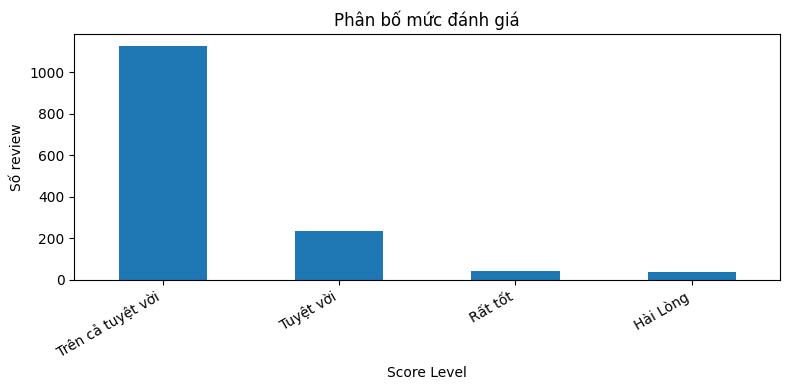

In [99]:
# Phân bố mức đánh giá của khách sạn.

score_level_summary = (
    selected_reviews
    .groupby("score_level")
    .size()
    .sort_values(
        ascending=False
    )
    .rename("review_count")
    .reset_index()
)

score_level_summary[
    "percentage"
] = (
    score_level_summary[
        "review_count"
    ]
    / score_level_summary[
        "review_count"
    ].sum()
    * 100
).round(2)

display(score_level_summary)

score_level_summary.set_index(
    "score_level"
)["review_count"].plot(
    kind="bar",
    figsize=(8, 4),
)

plt.title(
    "Phân bố mức đánh giá"
)
plt.xlabel(
    "Score Level"
)
plt.ylabel(
    "Số review"
)
plt.xticks(
    rotation=30,
    ha="right",
)
plt.tight_layout()
plt.show()

## 9.2. Strength and Weakness

So sánh các tiêu chí của khách sạn với:

- trung bình của các khách sạn còn lại trong hệ thống.
- trung bình của các khách sạn cùng hạng sao.

In [100]:
criteria = {
    "location": "Vị trí",
    "cleanliness": "Sạch sẽ",
    "service": "Dịch vụ",
    "facilities": "Tiện nghi",
    "value_for_money": "Đáng giá tiền",
    "comfort_and_room_quality": (
        "Thoải mái & chất lượng phòng"
    ),
}

other_hotels = hotel_info[
    hotel_info["hotel_id"].ne(
        selected_hotel_id
    )
]

same_rank_hotels = other_hotels[
    other_hotels["hotel_rank"].eq(
        selected_hotel_info[
            "hotel_rank"
        ]
    )
]

benchmark_rows = []

for column, label in criteria.items():
    hotel_score = (
        selected_hotel_info[column]
    )

    system_average = (
        other_hotels[column].mean()
    )

    same_rank_average = (
        same_rank_hotels[column].mean()
    )

    if pd.isna(hotel_score):
        difference = np.nan
        status = "Không có dữ liệu"
    else:
        difference = (
            hotel_score
            - system_average
        )

        if difference >= 0.3:
            status = "Điểm mạnh"
        elif difference <= -0.3:
            status = "Cần cải thiện"
        else:
            status = (
                "Gần mức trung bình"
            )

    benchmark_rows.append(
        {
            "Tiêu chí": label,
            "Điểm khách sạn": (
                hotel_score
            ),
            "TB toàn hệ thống": (
                system_average
            ),
            "TB cùng hạng sao": (
                same_rank_average
            ),
            "Chênh lệch với hệ thống": (
                difference
            ),
            "Nhận xét": status,
        }
    )

benchmark_table = pd.DataFrame(
    benchmark_rows
)

display(
    benchmark_table.round(2)
)

,Tiêu chí,Điểm khách sạn,TB toàn hệ thống,TB cùng hạng sao,Chênh lệch với hệ thống,Nhận xét
0,Vị trí,8.6,8.27,8.69,0.33,Điểm mạnh
1,Sạch sẽ,9.2,8.12,8.58,1.08,Điểm mạnh
2,Dịch vụ,9.2,8.29,8.55,0.91,Điểm mạnh
3,Tiện nghi,9.2,7.90,8.40,1.30,Điểm mạnh
4,Đáng giá tiền,9.2,8.18,8.63,1.02,Điểm mạnh
5,Thoải mái & chất lượng phòng,<NA>,8.30,9.08,NaN,Không có dữ liệu


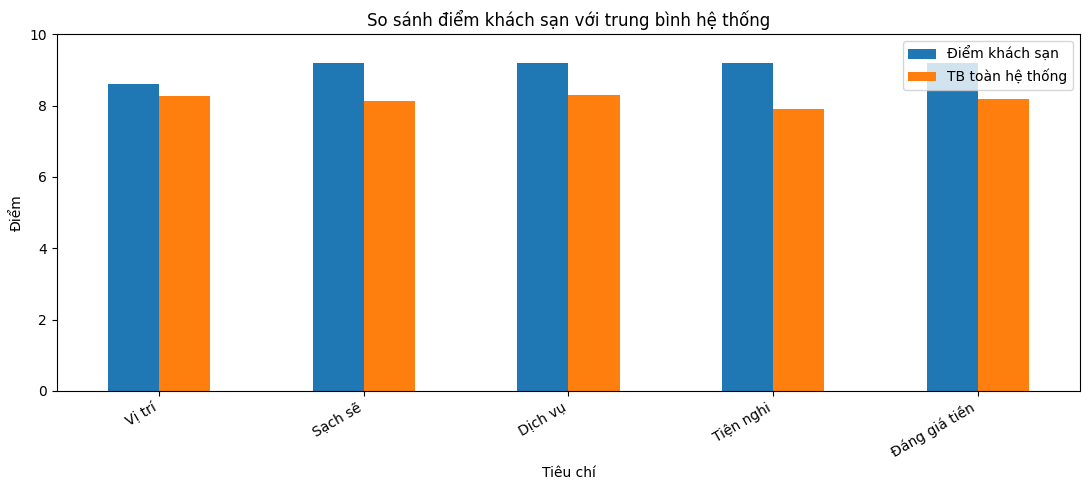

In [101]:
# Trực quan hóa điểm khách sạn và trung bình toàn hệ thống.

benchmark_plot_data = (
    benchmark_table
    .dropna(
        subset=[
            "Điểm khách sạn",
            "TB toàn hệ thống",
        ]
    )
    .set_index("Tiêu chí")[
        [
            "Điểm khách sạn",
            "TB toàn hệ thống",
        ]
    ]
)

benchmark_plot_data.plot(kind="bar",figsize=(11, 5))
plt.title("So sánh điểm khách sạn với trung bình hệ thống")
plt.xlabel("Tiêu chí")
plt.ylabel("Điểm")
plt.xticks(rotation=30, ha="right",)
plt.ylim(0, 10)
plt.tight_layout()
plt.show()

In [102]:
# Xác định tiêu chí nổi bật nhất và tiêu chí có chênh lệch thấp nhất.

valid_benchmark = (
    benchmark_table
    .dropna(
        subset=[
            "Chênh lệch với hệ thống"
        ]
    )
    .sort_values(
        "Chênh lệch với hệ thống",
        ascending=False,
    )
)

best_criterion = (valid_benchmark.iloc[0])
lowest_criterion = (valid_benchmark.iloc[-1])

print(
    "Tiêu chí nổi bật nhất:",
    best_criterion["Tiêu chí"],
    f"({best_criterion['Chênh lệch với hệ thống']:+.2f})",
)

if (lowest_criterion["Chênh lệch với hệ thống"] < 0):
    print(
        "Tiêu chí cần ưu tiên:",
        lowest_criterion["Tiêu chí"],
        f"({lowest_criterion['Chênh lệch với hệ thống']:+.2f})",
    )
else:
    print("Không có tiêu chí nào thấp hơn trung bình hệ thống.")
    print(
        "Tiêu chí có lợi thế nhỏ nhất:",
        lowest_criterion["Tiêu chí"],
        f"({lowest_criterion['Chênh lệch với hệ thống']:+.2f})",
    )

Tiêu chí nổi bật nhất: Tiện nghi (+1.30)
Không có tiêu chí nào thấp hơn trung bình hệ thống.
Tiêu chí có lợi thế nhỏ nhất: Vị trí (+0.33)


## 9.3. Analyze Customer

Phân tích:

- quốc tịch phổ biến;
- nhóm khách phổ biến;
- điểm trung bình của từng nhóm.


In [103]:
MIN_NATIONALITY_REVIEWS = 20
MIN_GROUP_REVIEWS = 20

nationality_summary = (
    selected_reviews
    .groupby("nationality")
    .agg(review_count=("score", "size"), average_score=("score", "mean"))
    .reset_index()
)

nationality_summary = (
    nationality_summary[nationality_summary["review_count"] >= MIN_NATIONALITY_REVIEWS]
    .sort_values("review_count", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

nationality_summary["average_score"] = nationality_summary["average_score"].round(2)

display(nationality_summary)

,nationality,review_count,average_score
0,Hàn Quốc,744,9.39
1,Việt Nam,414,9.39
2,Hồng Kông,114,9.43
3,Úc,36,9.47
4,Malaysia,24,9.8


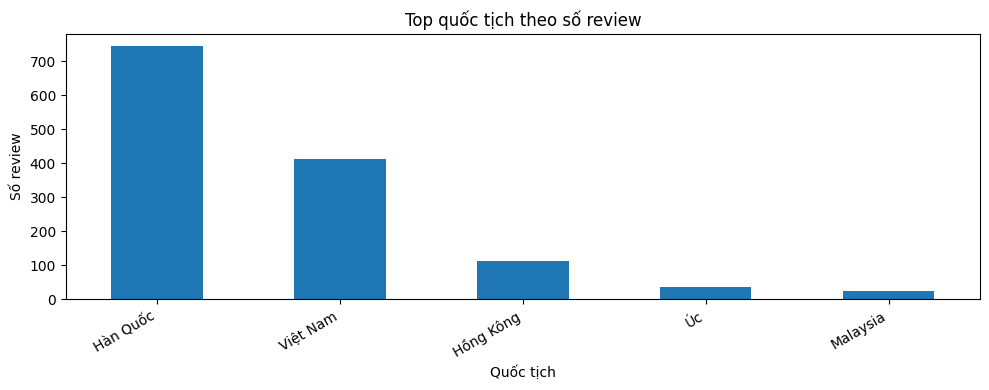

In [104]:
nationality_summary.set_index("nationality")["review_count"].plot(kind="bar",figsize=(10, 4))

plt.title("Top quốc tịch theo số review")
plt.xlabel("Quốc tịch")
plt.ylabel("Số review")
plt.xticks(rotation=30,ha="right")
plt.tight_layout()
plt.show()

In [105]:
group_summary = (
    selected_reviews
    .groupby("group_name")
    .agg(
        review_count=(
            "score",
            "size",
        ),
        average_score=(
            "score",
            "mean",
        ),
    )
    .reset_index()
)

group_summary = (
    group_summary[
        group_summary[
            "review_count"
        ]
        >= MIN_GROUP_REVIEWS
    ]
    .sort_values(
        "review_count",
        ascending=False,
    )
    .reset_index(drop=True)
)

group_summary[
    "average_score"
] = group_summary[
    "average_score"
].round(2)

display(group_summary)

,group_name,review_count,average_score
0,Gia đình có em bé,780,9.44
1,Cặp đôi,252,9.38
2,Nhóm,204,9.35
3,Gia đình có trẻ em,150,9.18
4,Du lịch một mình,42,9.37


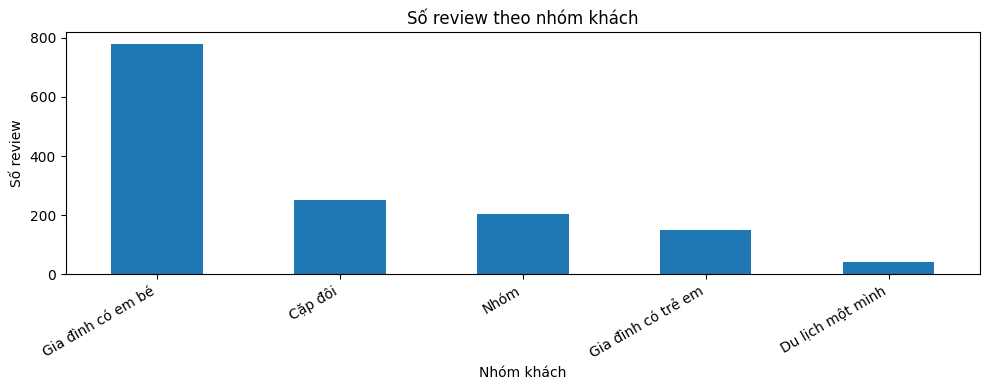

In [106]:
group_summary.set_index(
    "group_name"
)["review_count"].plot(
    kind="bar",
    figsize=(10, 4),
)

plt.title(
    "Số review theo nhóm khách"
)
plt.xlabel(
    "Nhóm khách"
)
plt.ylabel(
    "Số review"
)
plt.xticks(
    rotation=30,
    ha="right",
)
plt.tight_layout()
plt.show()

## 9.4. Trend over time

Phân tích theo năm:

- số review;
- điểm review trung bình.

In [107]:
yearly_summary = (
    selected_reviews
    .dropna(
        subset=[
            "review_date"
        ]
    )
    .assign(
        review_year=lambda data: (
            data[
                "review_date"
            ].dt.year
        )
    )
    .groupby(
        "review_year"
    )
    .agg(
        review_count=(
            "score",
            "size",
        ),
        average_score=(
            "score",
            "mean",
        ),
    )
    .reset_index()
)

yearly_summary[
    "average_score"
] = yearly_summary[
    "average_score"
].round(2)

display(yearly_summary)

,review_year,review_count,average_score
0,2020,18,10.0
1,2021,18,8.13
2,2022,150,9.46
3,2023,480,9.38
4,2024,774,9.4


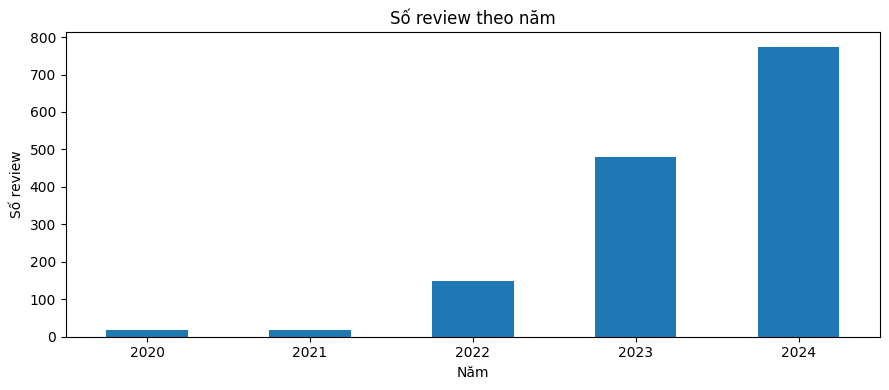

In [108]:
yearly_summary.set_index(
    "review_year"
)["review_count"].plot(
    kind="bar",
    figsize=(9, 4),
)

plt.title(
    "Số review theo năm"
)
plt.xlabel(
    "Năm"
)
plt.ylabel(
    "Số review"
)
plt.xticks(
    rotation=0
)
plt.tight_layout()
plt.show()

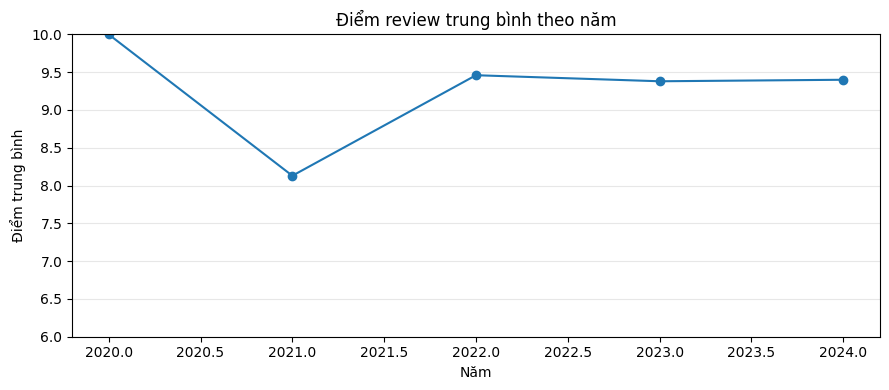

In [109]:
yearly_summary.set_index(
    "review_year"
)["average_score"].plot(
    kind="line",
    marker="o",
    figsize=(9, 4),
)

plt.title(
    "Điểm review trung bình theo năm"
)
plt.xlabel(
    "Năm"
)
plt.ylabel(
    "Điểm trung bình"
)
plt.ylim(6, 10)
plt.grid(
    axis="y",
    alpha=0.3,
)
plt.tight_layout()
plt.show()

## 9.5. Analyze keywords in reviews


In [110]:
from sklearn.feature_extraction.text import (
    CountVectorizer,
    ENGLISH_STOP_WORDS,
)

# Bổ sung một số từ phổ biến nhưng ít giá trị phân tích.
extra_stopwords = set(
    "đã rất thì mình tôi chúng bạn ở không cũng nên sẽ "
    "về nhưng vì nhiều hơn lại đây đó nếu để như ra vào "
    "trên dưới cả khách sạn hotel resort tuyệt vời".split()
)

# Loại các từ có trong chính tên khách sạn.
hotel_name_words = set(
    re.findall(
        r"[a-zA-ZÀ-ỹ]+",
        SELECTED_HOTEL.lower(),
    )
)

keyword_stopwords = list(
    set(vietnamese_stopwords)
    | set(ENGLISH_STOP_WORDS)
    | extra_stopwords
    | hotel_name_words
)


def get_top_keywords(
    text_series,
    top_n=15,
):
    # Chuyển về chữ thường và bỏ ký tự đặc biệt.
    clean_texts = (
        text_series
        .fillna("")
        .astype(str)
        .str.lower()
        .str.replace(
            r"[^a-zA-ZÀ-ỹ\s]",
            " ",
            regex=True,
        )
        .str.replace(
            r"\s+",
            " ",
            regex=True,
        )
        .str.strip()
    )

    # Đếm từ đơn và cụm hai từ.
    vectorizer = CountVectorizer(
        stop_words=keyword_stopwords,
        ngram_range=(1, 2),
        min_df=2,
    )

    word_matrix = vectorizer.fit_transform(
        clean_texts
    )

    keyword_table = pd.DataFrame(
        {
            "keyword": (
                vectorizer
                .get_feature_names_out()
            ),
            "frequency": np.asarray(
                word_matrix.sum(axis=0)
            ).ravel(),
        }
    )

    return (
        keyword_table
        .nlargest(
            top_n,
            "frequency",
        )
        .reset_index(drop=True)
    )

In [111]:
# Ghép tiêu đề và nội dung review.
selected_reviews["keyword_text"] = (
    selected_reviews["title"].fillna("")
    + " "
    + selected_reviews["body"].fillna("")
)

# Chia review thành hai nhóm.
high_score_reviews = selected_reviews[
    selected_reviews["score"] >= 9
]

lower_score_reviews = selected_reviews[
    selected_reviews["score"] < 9
]

# Lấy top từ khóa của mỗi nhóm.
positive_keywords = get_top_keywords(
    high_score_reviews["keyword_text"]
)

improvement_keywords = get_top_keywords(
    lower_score_reviews["keyword_text"]
)

print(
    "Review điểm cao:",
    len(high_score_reviews),
)

print(
    "Review điểm thấp hơn:",
    len(lower_score_reviews),
)

print("\nTỪ KHÓA TRONG REVIEW ĐIỂM CAO")
display(positive_keywords)

print("\nTỪ KHÓA TRONG REVIEW ĐIỂM THẤP HƠN")
display(improvement_keywords)

Review điểm cao: 1128
Review điểm thấp hơn: 312

TỪ KHÓA TRONG REVIEW ĐIỂM CAO


,keyword,frequency
0,good,240
1,phòng,174
2,ăn,144
3,biển,138
4,nhà,138
5,gia,132
6,gia đình,132
7,staff,132
8,đình,132
9,hàng,126



TỪ KHÓA TRONG REVIEW ĐIỂM THẤP HƠN


,keyword,frequency
0,good,126
1,staff,78
2,room,60
3,service,60
4,water,60
5,family,54
6,food,54
7,nice,54
8,time,54
9,hàng,48


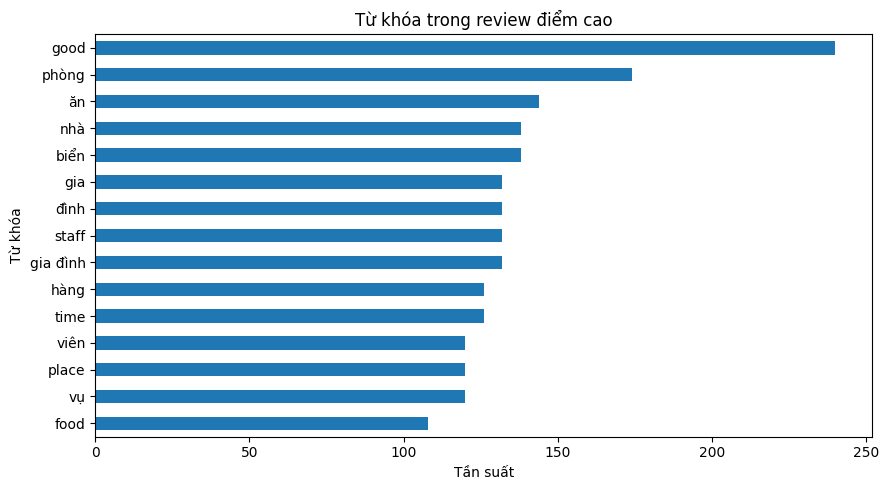

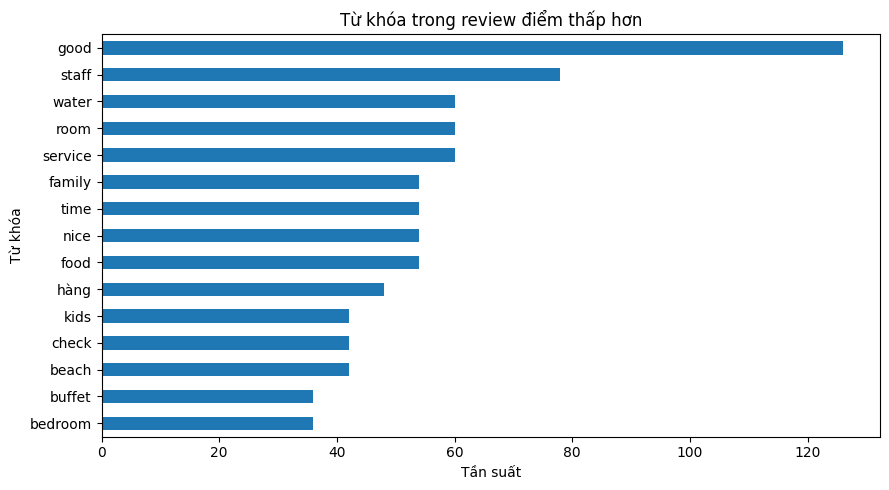

In [112]:
def plot_keywords(
    keyword_table,
    title,
):
    (
        keyword_table
        .sort_values("frequency")
        .plot(
            kind="barh",
            x="keyword",
            y="frequency",
            legend=False,
            figsize=(9, 5),
        )
    )

    plt.title(title)
    plt.xlabel("Tần suất")
    plt.ylabel("Từ khóa")
    plt.tight_layout()
    plt.show()


plot_keywords(
    positive_keywords,
    "Từ khóa trong review điểm cao",
)

plot_keywords(
    improvement_keywords,
    "Từ khóa trong review điểm thấp hơn",
)

In [113]:
# Xem 10 review có điểm thấp nhất để hiểu ngữ cảnh.

lowest_score_reviews = (
    selected_reviews
    .sort_values("score")
    .drop_duplicates(
        subset=[
            "title",
            "body",
        ]
    )
    .head(10)
    [
        [
            "score",
            "nationality",
            "group_name",
            "title",
            "body",
        ]
    ]
    .reset_index(drop=True)
)

display(lowest_score_reviews)

,score,nationality,group_name,title,body
0,6.4,Việt Nam,Gia đình có em bé,Giá phòng và dịch vụ rất cao nhưng không xứng đáng.”,"Giá phòng đắt hơn so với resort khác nhưng chất lượng kém, đặc biệt nhân viên không thân thiện, không cười và chào k..."
1,6.4,Hàn Quốc,Gia đình có em bé,알마리조트 4박 후기”,조경 및 수영장이 훌륭합니다. 밤에 산책할때 리조트의 야경을 제대로 만끽할 수 있습니다. 다만 리조트내 푸드코트 및 레스토랑들의 가격이 터무니없으며 맛이 없습니다. 그런데 리조트 내규로 배달을 금지했습니다. ...
2,6.8,Việt Nam,Gia đình có em bé,Great venue but low quality service”,"Stayed in family for 4 nights. Hotel is well equipped with great entertaining equipments (eg. Water parks, games in ..."
3,6.8,Hàn Quốc,Nhóm,good”,good
4,6.8,Việt Nam,Gia đình có trẻ em,Not really worthy of 5-star resort”,I went to Alma with my mom for the holidays (30/4-3/5). Customer experience here is under average. Had problem check...
5,6.8,Hàn Quốc,Cặp đôi,예약미스 & 친절한 직원”,"아고다, 알마 둘 중 한 곳에서 방 배정을 잘못해줬지만 친절한 직원분이 다시 잘 안내해줘서 편히 잘 쉬다 갑니다."
6,7.2,Hoa Kỳ,Gia đình có trẻ em,"Great service and room, but everything else is horrible”","The room and views are pleasing with incredibly nice staff, but the same can’t be said for anything else. The game r..."
7,7.6,Hàn Quốc,Gia đình có em bé,The good and bad”,"The resort itself is amazing but it’s in the middle of nowhere. Next time, we will book something closer to Nha Tran..."
8,7.6,Pháp,Gia đình có em bé,Nice beach and villa ”,Wonderful villa except the AC system which is mis configured. So we are unable to use the AC in the living room and ...
9,7.6,Việt Nam,Cặp đôi,"For family, big group of friends but not for couple expecting privacy”","very full package holiday for family and big group of friends. multiple activities to do like water sports, arcade g..."


TÓM TẮT INSIGHT
1. Khách sạn có 1,440 review, điểm review trung bình 9.39/10.
2. Nhóm khách lớn nhất là Gia đình có em bé (780 review).
3. Quốc tịch phổ biến nhất là Hàn Quốc (744 review).
4. Tất cả tiêu chí có dữ liệu đều cao hơn trung bình hệ thống. Vị trí là tiêu chí có lợi thế nhỏ nhất (+0.33).
5. Điểm trung bình năm 2024 tăng 0.02 điểm so với năm 2023.

In [114]:
spark.stop()
print("Spark session stopped.")

Spark session stopped.


# 10. Deployment Artifact Export (Preparation for Streamlit App)

In [115]:
# Cài thư viện để lưu dữ liệu dạng Parquet.
!pip -q install pyarrow

## 10.1. Export artifacts for Streamlit

In [116]:
from pathlib import Path
import json
import shutil

import joblib
import numpy as np
import pandas as pd
import pyarrow
import scipy
import sklearn

from scipy import sparse


# Thư mục chứa tất cả file dùng cho Streamlit.
DEPLOY_ROOT = Path("/content/project1_streamlit_export")
ARTIFACT_DIR = DEPLOY_ROOT / "artifacts"

ARTIFACT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ------------------------------------------------------------
# 1. Chuẩn bị hotel_info
# ------------------------------------------------------------

# Reset index nhưng không đổi thứ tự dòng.
# Thứ tự này phải khớp với thứ tự các dòng trong TF-IDF matrix.
hotel_info_deploy = (
    hotel_info
    .reset_index(drop=True)
    .copy()
)

# content_row là vị trí của khách sạn trong TF-IDF matrix.
hotel_info_deploy.insert(
    0,
    "content_row",
    np.arange(len(hotel_info_deploy)),
)


# ------------------------------------------------------------
# 2. Chuẩn bị hotel_comments
# ------------------------------------------------------------

hotel_comments_deploy = hotel_comments.copy()

hotel_comments_deploy["review_date"] = pd.to_datetime(
    hotel_comments_deploy["review_date"],
    errors="coerce",
)


# ------------------------------------------------------------
# 3. Kiểm tra các cột bắt buộc
# ------------------------------------------------------------

required_hotel_columns = {
    "hotel_id",
    "hotel_name",
    "hotel_rank",
    "hotel_address",
    "total_score",
    "comments_count",
    "location",
    "cleanliness",
    "service",
    "facilities",
    "value_for_money",
    "comfort_and_room_quality",
    "content_row",
}

required_comment_columns = {
    "hotel_id",
    "reviewer_id",
    "nationality",
    "group_name",
    "score",
    "score_level",
    "review_date",
    "title",
    "body",
}

missing_hotel_columns = (
    required_hotel_columns
    - set(hotel_info_deploy.columns)
)

missing_comment_columns = (
    required_comment_columns
    - set(hotel_comments_deploy.columns)
)

if missing_hotel_columns:
    raise ValueError(
        f"hotel_info thiếu cột: {missing_hotel_columns}"
    )

if missing_comment_columns:
    raise ValueError(
        f"hotel_comments thiếu cột: {missing_comment_columns}"
    )


# ------------------------------------------------------------
# 4. Lưu dữ liệu sạch
# ------------------------------------------------------------

hotel_info_deploy.to_parquet(
    ARTIFACT_DIR / "hotel_info_clean.parquet",
    index=False,
)

hotel_comments_deploy.to_parquet(
    ARTIFACT_DIR / "hotel_comments_clean.parquet",
    index=False,
)

cf_data.to_parquet(
    ARTIFACT_DIR / "cf_data.parquet",
    index=False,
)


# ------------------------------------------------------------
# 5. Lưu TF-IDF matrix
# ------------------------------------------------------------

# App gợi ý trong số các khách sạn đã có.
sparse.save_npz(
    ARTIFACT_DIR / "tfidf_matrix.npz",
    tfidf_matrix,
)

# 6. Export fitted TF-IDF vectorizer.
# App cần artifact này để biến câu tìm kiếm
# mới của người dùng thành TF-IDF vector.

joblib.dump(
    tfidf_vectorizer,
    ARTIFACT_DIR / "tfidf_vectorizer.joblib",
)


# ------------------------------------------------------------
# 7. Lưu Ridge model
# ------------------------------------------------------------

joblib.dump(
    ridge_full_model,
    ARTIFACT_DIR / "ridge_full_model.joblib",
)


# ------------------------------------------------------------
# 8. Lưu bảng đánh giá model
# ------------------------------------------------------------

model_comparison.to_csv(
    ARTIFACT_DIR / "model_comparison.csv",
    index=False,
)

## 10.2. Precompute Gensim Top-20 recommendations

In [117]:
def precompute_gensim_recommendations(
    hotel_catalog,
    top_n=20,
):
    rows = []

    for source_row in range(len(hotel_catalog)):
        query_vector = gensim_tfidf[
            corpus[source_row]
        ]

        scores = np.asarray(
            gensim_index[query_vector],
            dtype=float,
        )

        ranked_rows = np.argsort(scores)[::-1]

        ranked_rows = [
            int(row)
            for row in ranked_rows
            if int(row) != source_row
        ][:top_n]

        source_hotel_id = hotel_catalog.iloc[
            source_row
        ]["hotel_id"]

        for rank, recommended_row in enumerate(
            ranked_rows,
            start=1,
        ):
            recommended_hotel_id = hotel_catalog.iloc[
                recommended_row
            ]["hotel_id"]

            rows.append(
                {
                    "source_hotel_id": source_hotel_id,
                    "rank": rank,
                    "recommended_hotel_id": (
                        recommended_hotel_id
                    ),
                    "similarity_score": float(
                        scores[recommended_row]
                    ),
                }
            )

    return pd.DataFrame(rows)


gensim_top20 = precompute_gensim_recommendations(
    hotel_catalog=hotel_info_deploy,
    top_n=20,
)

gensim_top20.to_parquet(
    ARTIFACT_DIR / "gensim_top20.parquet",
    index=False,
)

print("Gensim recommendation rows:", len(gensim_top20))
display(gensim_top20.head())

Gensim recommendation rows: 14800


,source_hotel_id,rank,recommended_hotel_id,similarity_score
0,1_1,1,2_20,0.841910
1,1_1,2,2_8,0.827125
2,1_1,3,15_1,0.825240
3,1_1,4,8_15,0.825001
4,1_1,5,23_25,0.824928


## 10.3. Deployment summary

In [118]:
reviewed_hotel_ids = (
    set(hotel_info_deploy["hotel_id"])
    & set(hotel_comments_deploy["hotel_id"])
)

sample_hotel_row = hotel_info_deploy.loc[
    hotel_info_deploy["hotel_name"].eq(sample_hotel)
].iloc[0]

deployment_summary = {
    "hotel_info_rows": int(
        len(hotel_info_deploy)
    ),
    "hotel_comment_rows": int(
        len(hotel_comments_deploy)
    ),
    "content_based_hotels": int(
        hotel_info_deploy["hotel_id"].nunique()
    ),
    "hotels_with_reviews": int(
        len(reviewed_hotel_ids)
    ),
    "cf_interactions": int(
        len(cf_data)
    ),
    "customer_groups": int(
        cf_data["customer_group"].nunique()
    ),
    "cf_hotels": int(
        cf_data["hotel_id"].nunique()
    ),
    "sample_hotel_id": str(
        sample_hotel_row["hotel_id"]
    ),
    "sample_hotel_name": str(
        sample_hotel_row["hotel_name"]
    ),
    "content_top10_overlap": int(
        common_count
    ),
    "limitations": [
        (
            "Mỗi Reviewer ID chỉ có một interaction."
        ),
        (
            "Collaborative recommendation ở cấp "
            "customer group, không phải từng cá nhân."
        ),
        (
            "Một số Hotel ID không khớp giữa hai bảng."
        ),
        (
            "Chưa có ground truth recommendation để "
            "tính Precision@K hoặc Recall@K."
        ),
    ],
    "versions": {
        "pandas": pd.__version__,
        "numpy": np.__version__,
        "scipy": scipy.__version__,
        "scikit_learn": sklearn.__version__,
        "joblib": joblib.__version__,
        "pyarrow": pyarrow.__version__,
    },
}

with open(
    ARTIFACT_DIR / "deployment_summary.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        deployment_summary,
        file,
        ensure_ascii=False,
        indent=2,
    )

print(
    json.dumps(
        deployment_summary,
        ensure_ascii=False,
        indent=2,
    )
)

{
  "hotel_info_rows": 740,
  "hotel_comment_rows": 80314,
  "content_based_hotels": 740,
  "hotels_with_reviews": 341,
  "cf_interactions": 5490,
  "customer_groups": 147,
  "cf_hotels": 251,
  "sample_hotel_id": "1_24",
  "sample_hotel_name": "Khu nghỉ dưỡng Alma Cam Ranh (Alma Resort Cam Ranh)",
  "content_top10_overlap": 5,
  "limitations": [
    "Mỗi Reviewer ID chỉ có một interaction.",
    "Collaborative recommendation ở cấp customer group, không phải từng cá nhân.",
    "Một số Hotel ID không khớp giữa hai bảng.",
    "Chưa có ground truth recommendation để tính Precision@K hoặc Recall@K."
  ],
  "versions": {
    "pandas": "2.2.2",
    "numpy": "2.0.2",
    "scipy": "1.16.3",
    "scikit_learn": "1.6.1",
    "joblib": "1.5.3",
    "pyarrow": "18.1.0"
  }
}


## 10.4. Generate requirements.txt

In [119]:
requirements = [
    "streamlit>=1.40,<2",
    f"pandas=={pd.__version__}",
    f"numpy=={np.__version__}",
    f"scipy=={scipy.__version__}",
    f"scikit-learn=={sklearn.__version__}",
    f"joblib=={joblib.__version__}",
    f"pyarrow=={pyarrow.__version__}",
]

requirements_text = "\n".join(requirements) + "\n"

requirements_path = (
    DEPLOY_ROOT / "requirements.txt"
)

requirements_path.write_text(
    requirements_text,
    encoding="utf-8",
)

print(requirements_text)

streamlit>=1.40,<2
pandas==2.2.2
numpy==2.0.2
scipy==1.16.3
scikit-learn==1.6.1
joblib==1.5.3
pyarrow==18.1.0



## 10.5. Validate exported artifacts

In [120]:
from sklearn.metrics.pairwise import (
    cosine_similarity,
)


# Load lại dữ liệu từ file.
loaded_hotel_info = pd.read_parquet(
    ARTIFACT_DIR / "hotel_info_clean.parquet"
)

loaded_comments = pd.read_parquet(
    ARTIFACT_DIR / "hotel_comments_clean.parquet"
)

loaded_cf_data = pd.read_parquet(
    ARTIFACT_DIR / "cf_data.parquet"
)

loaded_tfidf = sparse.load_npz(
    ARTIFACT_DIR / "tfidf_matrix.npz"
)

loaded_ridge = joblib.load(
    ARTIFACT_DIR / "ridge_full_model.joblib"
)

loaded_gensim = pd.read_parquet(
    ARTIFACT_DIR / "gensim_top20.parquet"
)


# 1. Kiểm tra số dòng.
assert len(loaded_hotel_info) == len(hotel_info)
assert len(loaded_comments) == len(hotel_comments)
assert len(loaded_cf_data) == len(cf_data)


# 2. Kiểm tra TF-IDF matrix.
assert loaded_tfidf.shape[0] == len(
    loaded_hotel_info
)


# 3. Kiểm tra Gensim.
expected_gensim_rows = (
    len(loaded_hotel_info) * 20
)

assert len(loaded_gensim) == expected_gensim_rows


# 4. Kiểm tra Cosine với khách sạn mẫu.
sample_row = int(
    loaded_hotel_info.loc[
        loaded_hotel_info["hotel_name"].eq(
            sample_hotel
        ),
        "content_row",
    ].iloc[0]
)

sample_scores = cosine_similarity(
    loaded_tfidf[sample_row],
    loaded_tfidf,
).ravel()

assert len(sample_scores) == len(
    loaded_hotel_info
)


# 5. Kiểm tra Ridge model.
sample_customer_group = "Hàn Quốc | Cặp đôi"

candidate_ids = (
    loaded_cf_data["hotel_id"]
    .drop_duplicates()
    .head(5)
    .tolist()
)

sample_candidates = pd.DataFrame(
    {
        "customer_group": (
            sample_customer_group
        ),
        "hotel_id": candidate_ids,
    }
)

sample_predictions = loaded_ridge.predict(
    sample_candidates[
        ["customer_group", "hotel_id"]
    ]
)

assert len(sample_predictions) == 5
assert np.isfinite(sample_predictions).all()

loaded_vectorizer = joblib.load(
    ARTIFACT_DIR / "tfidf_vectorizer.joblib"
)

loaded_tfidf = sparse.load_npz(
    ARTIFACT_DIR / "tfidf_matrix.npz"
)

sample_query = (
    "resort khu nghỉ dưỡng "
    "rank5 cam ranh"
)

sample_query_vector = (
    loaded_vectorizer.transform(
        [sample_query]
    )
)

print(
    "Query vector shape:",
    sample_query_vector.shape,
)

print(
    "TF-IDF matrix shape:",
    loaded_tfidf.shape,
)

print(
    "Non-zero query features:",
    sample_query_vector.nnz,
)

assert (
    "rank5"
    in loaded_vectorizer.vocabulary_
)

assert (
    sample_query_vector.shape[1]
    == loaded_tfidf.shape[1]
)

assert sample_query_vector.nnz > 0

print("TF-IDF search artifact validation passed.")

print("All deployment artifacts passed validation.")
print("TF-IDF shape:", loaded_tfidf.shape)
print("Gensim rows:", len(loaded_gensim))
print("Sample Ridge predictions:", sample_predictions)

Query vector shape: (1, 15000)
TF-IDF matrix shape: (740, 15000)
Non-zero query features: 11
TF-IDF search artifact validation passed.
All deployment artifacts passed validation.
TF-IDF shape: (740, 15000)
Gensim rows: 14800
Sample Ridge predictions: [9.43078573 9.14654405 9.18943854 8.367629   9.57086202]


## 10.6. Download deployment package

In [121]:
zip_path = shutil.make_archive(
    base_name="/content/project1_streamlit_export",
    format="zip",
    root_dir="/content",
    base_dir="project1_streamlit_export",
)

print("Created:", zip_path)

Created: /content/project1_streamlit_export.zip


In [ ]:
# Optional — Google Colab only
# download file to computer
# from google.colab import files

# files.download(
#     "/content/project1_streamlit_export.zip"
# )

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 11. Conclusion

This project developed an end-to-end hotel recommendation and customer insights workflow, from data preparation and model evaluation to deployment-ready artifacts.

### Key Results

- **TF-IDF + Cosine Similarity** was selected as the primary content-based recommendation approach because it is simple, interpretable, efficient, and directly supports free-text hotel search.
- The TF-IDF/Cosine and Gensim approaches shared **5 of the Top-10 recommendations** in the deployment evaluation, indicating moderate agreement between the two methods.
- For customer-group recommendation, **One-Hot Encoding + Ridge Regression** achieved the best test performance with **RMSE = 0.8260** and **MAE = 0.6307**, outperforming both the Global Mean baseline and PySpark ALS.
- **PySpark ALS** was implemented and evaluated as the distributed collaborative-filtering approach, while Ridge Regression was selected for the deployed application.
- Hotel review analysis provides additional insights into rating criteria, customer segments, review trends, recurring keywords, and low-scoring reviews.
- The final pipeline exports cleaned data, TF-IDF artifacts, the trained Ridge model, and evaluation summaries for direct use by the Streamlit application.

### Important Limitations

- Each Reviewer ID contains only one interaction, so reliable individual-level collaborative filtering is not possible with the available data.
- Collaborative recommendations therefore operate at the **customer-group level**.
- Some Hotel IDs are not fully aligned between the hotel-information and review datasets.
- The dataset does not provide recommendation ground truth, so metrics such as Precision@K and Recall@K cannot be calculated.

### Deployment

The trained artifacts from this notebook are consumed by the Streamlit application without retraining at runtime.

The deployed application adds free-text hotel search, similar-hotel recommendations, customer-group recommendations, hotel insights, bilingual UI, and a product-style recommendation interface.